# Шаг 1: Установка необходимых библиотек

In [1]:
!pip install "gymnasium[atari]" imageio[ffmpeg]
!pip install autorom[accept-rom-license]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 7.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for AutoROM.accept-rom-license: filename=autorom_accept_rom_license-0.6.1-py3-none-any.whl size=446710 sha256=5e388508b9a1d0602921cb42d550f5c3d949d766feeb360f8ac7a1deb776cbb3
  Stored in directory: /root/.cache/pip/wheels/99/f1/ff/c6966c034a8259164bdc9deb4d1ea839f119474638100e6645
Successfully built AutoROM.accept-rom-license


# Шаг 2: Импорт библиотек и регистрация окружений

In [2]:
import gymnasium as gym
import ale_py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import imageio
import matplotlib.pyplot as plt
from IPython.display import Video, display
import random
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Регистрируем окружения Atari
gym.register_envs(ale_py)

# Шаг 3: Создание нейросети для политики

In [3]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_shape, n_actions):
        super(PolicyNetwork, self).__init__()
        # Сверточная часть для обработки изображений
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # Полносвязная часть
        # Рассчитываем размер после сверток
        with torch.no_grad():
            dummy = torch.zeros(1, 1, *input_shape)
            conv_out = self.conv(dummy).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(conv_out, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

    def get_action(self, state):
        """Выбор действия на основе состояния"""
        with torch.no_grad():
            logits = self.forward(state)
            probs = F.softmax(logits, dim=-1)
            action = torch.multinomial(probs, 1).item()
            return action

# Шаг 4: Функция предобработки изображений

In [4]:
def preprocess_frame(frame):
    """Преобразование кадра в черно-белый и уменьшение размера"""
    # Конвертируем в grayscale
    if len(frame.shape) == 3:
        frame = np.mean(frame, axis=2).astype(np.uint8)

    # Уменьшаем размер до 84x84
    from skimage.transform import resize
    frame = resize(frame, (84, 84), preserve_range=True, anti_aliasing=True).astype(np.uint8)

    # Нормализуем
    frame = frame / 255.0
    return frame.astype(np.float32)

# Шаг 5: Функция для запуска одного эпизода

In [5]:
def run_episode(env, policy_network, device='cpu', render=False):
    """
    Запускает один эпизод игры с заданной политикой
    Возвращает общую награду и список кадров (если render=True)
    """
    state, info = env.reset()
    state = preprocess_frame(state)
    total_reward = 0
    done = False
    frames = []

    while not done:
        # Подготавливаем состояние для нейросети
        state_tensor = torch.FloatTensor(state).unsqueeze(0).unsqueeze(0).to(device)

        # Выбираем действие
        action = policy_network.get_action(state_tensor)

        # Делаем шаг в среде
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Обрабатываем следующий кадр
        next_state = preprocess_frame(next_state)

        # Сохраняем кадр если нужно
        if render:
            frames.append(env.render())

        total_reward += reward
        state = next_state

    return total_reward, frames

# Шаг 6: Случайный поиск

In [6]:
def random_search(env, input_shape, n_actions, n_episodes=50, device='cpu'):
    """
    Реализация стратегии случайного поиска
    """
    print("=" * 50)
    print("Запуск случайного поиска...")
    print("=" * 50)

    best_reward = -float('inf')
    best_weights = None
    rewards_history = []

    for episode in range(n_episodes):
        # Создаем новую сеть со случайными весами
        policy = PolicyNetwork(input_shape, n_actions).to(device)

        # Запускаем эпизод
        episode_reward, _ = run_episode(env, policy, device)
        rewards_history.append(episode_reward)

        # Сохраняем лучший результат
        if episode_reward > best_reward:
            best_reward = episode_reward
            best_weights = {k: v.clone() for k, v in policy.state_dict().items()}

        if (episode + 1) % 10 == 0:
            print(f"Эпизод {episode + 1}/{n_episodes}, Награда: {episode_reward:.2f}, Лучшая: {best_reward:.2f}")

    print(f"\nЛучшая награда при случайном поиске: {best_reward:.2f}")
    return best_weights, best_reward, rewards_history

# Шаг 7: Восхождение на вершину

In [7]:
def hill_climbing(env, input_shape, n_actions, initial_weights=None,
                  n_iterations=100, noise_scale=0.1, device='cpu'):
    """
    Реализация стратегии восхождения на вершину
    """
    print("=" * 50)
    print("Запуск восхождения на вершину...")
    print("=" * 50)

    # Создаем начальную политику
    current_policy = PolicyNetwork(input_shape, n_actions).to(device)

    # Если есть начальные веса, загружаем их
    if initial_weights is not None:
        current_policy.load_state_dict(initial_weights)

    # Оцениваем начальную политику
    current_reward, _ = run_episode(env, current_policy, device)
    best_reward = current_reward
    best_weights = {k: v.clone() for k, v in current_policy.state_dict().items()}

    rewards_history = [current_reward]

    print(f"Начальная награда: {current_reward:.2f}")

    for iteration in range(n_iterations):
        # Создаем кандидата, добавляя шум к весам
        candidate_policy = PolicyNetwork(input_shape, n_actions).to(device)
        candidate_policy.load_state_dict(current_policy.state_dict())

        # Добавляем шум к весам
        with torch.no_grad():
            for param in candidate_policy.parameters():
                param.add_(torch.randn_like(param) * noise_scale)

        # Оцениваем кандидата
        candidate_reward, _ = run_episode(env, candidate_policy, device)
        rewards_history.append(candidate_reward)

        # Если кандидат лучше, принимаем его
        if candidate_reward > current_reward:
            current_policy.load_state_dict(candidate_policy.state_dict())
            current_reward = candidate_reward

            # Обновляем лучший результат
            if current_reward > best_reward:
                best_reward = current_reward
                best_weights = {k: v.clone() for k, v in current_policy.state_dict().items()}

            print(f"Итерация {iteration + 1}: улучшение! Новая награда: {current_reward:.2f}")
        else:
            if (iteration + 1) % 20 == 0:
                print(f"Итерация {iteration + 1}: без улучшения ({candidate_reward:.2f} <= {current_reward:.2f})")

    print(f"\nЛучшая награда при восхождении на вершину: {best_reward:.2f}")
    return best_weights, best_reward, rewards_history

# Шаг 8: Создание видео

In [8]:
def create_video(env, policy_network, filename='pacman_best_game.mp4', fps=30, device='cpu'):
    """
    Создает видео игры с заданной политикой
    """
    print(f"Создание видео {filename}...")

    # Создаем окружение с рендерингом
    video_env = gym.make("ALE/MsPacman-v5", render_mode='rgb_array')

    # Запускаем эпизод с сохранением кадров
    _, frames = run_episode(video_env, policy_network, device, render=True)

    # Сохраняем видео
    if frames:
        imageio.mimsave(filename, frames, fps=fps)
        print(f"Видео сохранено как {filename}")
    else:
        print("Не удалось создать видео")

    video_env.close()
    return filename

# Шаг 9: Основной код выполнения

In [9]:
def main():
    print("=" * 50)
    print("Обучение модели для игры Pac-Man")
    print("=" * 50)

    # Создаем окружение для получения информации
    env = gym.make("ALE/MsPacman-v5")

    # Получаем информацию о пространстве действий
    n_actions = env.action_space.n
    print(f"Количество действий: {n_actions}")

    # Получаем пробное состояние для определения размера входных данных
    state, _ = env.reset()
    processed_state = preprocess_frame(state)
    input_shape = processed_state.shape

    print(f"Размер входных данных: {input_shape}")

    # Устройство для вычислений
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Используется устройство: {device}")

    # Закрываем временное окружение
    env.close()

    # Шаг 1: Случайный поиск
    print("\n" + "=" * 50)
    print("ЭТАП 1: СЛУЧАЙНЫЙ ПОИСК")
    print("=" * 50)

    # Создаем новое окружение для обучения
    train_env = gym.make("ALE/MsPacman-v5")

    random_weights, random_reward, random_history = random_search(
        train_env, input_shape, n_actions, n_episodes=50, device=device
    )

    # Шаг 2: Восхождение на вершину
    print("\n" + "=" * 50)
    print("ЭТАП 2: ВОСХОЖДЕНИЕ НА ВЕРШИНУ")
    print("=" * 50)

    # Используем лучшие веса от случайного поиска как начальные
    hill_weights, hill_reward, hill_history = hill_climbing(
        train_env, input_shape, n_actions,
        initial_weights=random_weights,
        n_iterations=100, noise_scale=0.1, device=device
    )

    train_env.close()

    # Шаг 3: Сравнение результатов
    print("\n" + "=" * 50)
    print("РЕЗУЛЬТАТЫ")
    print("=" * 50)
    print(f"Случайный поиск - лучшая награда: {random_reward:.2f}")
    print(f"Восхождение на вершину - лучшая награда: {hill_reward:.2f}")

    # Определяем лучшую стратегию
    if hill_reward > random_reward:
        print("\n✅ Восхождение на вершину показало лучший результат!")
        best_weights = hill_weights
        best_reward = hill_reward
        best_strategy = "hill_climbing"
    else:
        print("\n✅ Случайный поиск показал лучший результат!")
        best_weights = random_weights
        best_reward = random_reward
        best_strategy = "random_search"

    # Шаг 4: Визуализация процесса обучения
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(random_history, 'b-', alpha=0.7)
    plt.xlabel('Эпизод')
    plt.ylabel('Награда')
    plt.title('Случайный поиск')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(hill_history, 'r-', alpha=0.7)
    plt.xlabel('Итерация')
    plt.ylabel('Награда')
    plt.title('Восхождение на вершину')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_results.png')
    plt.show()
    print("Графики сохранены как training_results.png")

    # Шаг 5: Создание видео с лучшей стратегией
    print("\n" + "=" * 50)
    print("СОЗДАНИЕ ВИДЕО С ЛУЧШЕЙ ИГРОЙ")
    print("=" * 50)

    # Создаем политику с лучшими весами
    best_policy = PolicyNetwork(input_shape, n_actions).to(device)
    best_policy.load_state_dict(best_weights)

    # Создаем видео
    video_filename = create_video(train_env, best_policy, 'pacman_best_game.mp4', device=device)

    # Отображаем видео в Colab
    print("\n" + "=" * 50)
    print("ВИДЕО ЛУЧШЕЙ ИГРЫ")
    print("=" * 50)
    display(Video(video_filename, embed=True, width=600))

    # Шаг 6: Итоговый отчет
    print("\n" + "=" * 50)
    print("ИТОГОВЫЙ ОТЧЕТ")
    print("=" * 50)
    print(f"""
    Игра: Ms Pac-Man (ALE/MsPacman-v5)
    Количество действий: {n_actions}

    Результаты обучения:

    1. Случайный поиск:
       - Лучшая награда: {random_reward:.2f}
       - Суть метода: генерация случайных весов нейросети и выбор лучшего результата
       - Преимущество: простота реализации, не требует градиентов

    2. Восхождение на вершину:
       - Лучшая награда: {hill_reward:.2f}
       - Суть метода: итеративное улучшение весов путем добавления шума
       - Преимущество: постепенное улучшение политики

    3. Сравнение:
       - Лучшая стратегия: {best_strategy}
       - Разница: {abs(hill_reward - random_reward):.2f} очков

    Вывод: {'Восхождение на вершину позволило улучшить результат за счет направленного поиска' if hill_reward > random_reward else 'Случайный поиск дал хороший результат, но hill climbing мог бы быть эффективнее при большем количестве итераций'}

    Видео с лучшей игрой сохранено как 'pacman_best_game.mp4'
    """)

# Запуск основной функции

Обучение модели для игры Pac-Man
Количество действий: 9
Размер входных данных: (84, 84)
Используется устройство: cpu

ЭТАП 1: СЛУЧАЙНЫЙ ПОИСК
Запуск случайного поиска...
Эпизод 10/50, Награда: 140.00, Лучшая: 340.00
Эпизод 20/50, Награда: 130.00, Лучшая: 340.00
Эпизод 30/50, Награда: 260.00, Лучшая: 530.00
Эпизод 40/50, Награда: 270.00, Лучшая: 530.00
Эпизод 50/50, Награда: 330.00, Лучшая: 640.00

Лучшая награда при случайном поиске: 640.00

ЭТАП 2: ВОСХОЖДЕНИЕ НА ВЕРШИНУ
Запуск восхождения на вершину...
Начальная награда: 240.00
Итерация 4: улучшение! Новая награда: 820.00
Итерация 5: улучшение! Новая награда: 840.00
Итерация 13: улучшение! Новая награда: 890.00
Итерация 20: без улучшения (210.00 <= 890.00)
Итерация 40: без улучшения (70.00 <= 890.00)
Итерация 60: без улучшения (90.00 <= 890.00)
Итерация 80: без улучшения (210.00 <= 890.00)
Итерация 100: без улучшения (210.00 <= 890.00)

Лучшая награда при восхождении на вершину: 890.00

РЕЗУЛЬТАТЫ
Случайный поиск - лучшая награда: 64

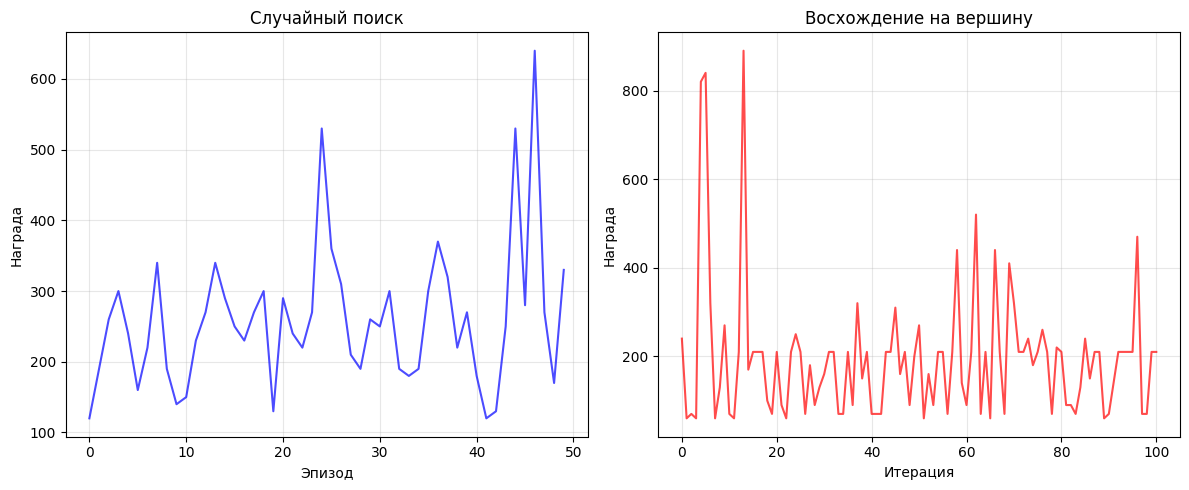

Графики сохранены как training_results.png

СОЗДАНИЕ ВИДЕО С ЛУЧШЕЙ ИГРОЙ
Создание видео pacman_best_game.mp4...


Видео сохранено как pacman_best_game.mp4

ВИДЕО ЛУЧШЕЙ ИГРЫ



ИТОГОВЫЙ ОТЧЕТ

    Игра: Ms Pac-Man (ALE/MsPacman-v5)
    Количество действий: 9
    
    Результаты обучения:
    
    1. Случайный поиск:
       - Лучшая награда: 640.00
       - Суть метода: генерация случайных весов нейросети и выбор лучшего результата
       - Преимущество: простота реализации, не требует градиентов
    
    2. Восхождение на вершину:
       - Лучшая награда: 890.00
       - Суть метода: итеративное улучшение весов путем добавления шума
       - Преимущество: постепенное улучшение политики
    
    3. Сравнение:
       - Лучшая стратегия: hill_climbing
       - Разница: 250.00 очков
       
    Вывод: Восхождение на вершину позволило улучшить результат за счет направленного поиска
    
    Видео с лучшей игрой сохранено как 'pacman_best_game.mp4'
    


In [10]:
if __name__ == "__main__":
    main()